# Conditional Lag-CRP

> Compute Lag-CRP while selectively excluding transitions and optionally using condition-specific target denominators.

The conditional Lag-CRP extends the standard Lag-CRP by adding a `_should_tabulate` mask that controls which transitions are counted. When the mask is `False` for a recall event, the tabulator still updates internal state (availability, previous positions) but does not increment lag tallies. It can also filter transitions by a source-item field and split available target denominators by a target-item field.


## Workflow

In [1]:
import os
import matplotlib.pyplot as plt
import warnings
from jaxcmr.analyses.conditional_crp import plot_crp
from jaxcmr.helpers import find_project_root, generate_trial_mask, load_data, save_figure

warnings.filterwarnings("ignore")

In [2]:
data_path = "data/HealeyKahana2014.h5"
figure_dir = "results/figures"
figure_str = ""
ylim = None
trial_query = "data['listtype'] == -1"
source_field = None
source_values = None
target_field = None
target_values = None


In [3]:
project_root = find_project_root()
figure_dir = os.path.join(project_root, figure_dir)
data_path = os.path.join(project_root, data_path)
data = load_data(data_path)
data["_should_tabulate"] = data["recalls"] > 0
trial_mask = generate_trial_mask(data, trial_query)

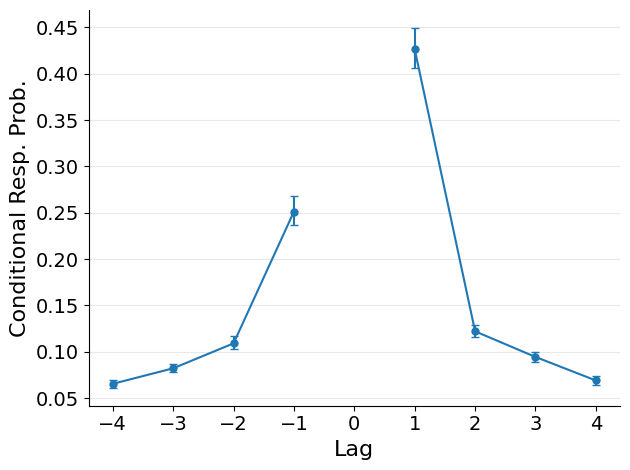

In [4]:
plot_crp(
    data,
    trial_mask,
    source_field=source_field,
    source_values=source_values,
    target_field=target_field,
    target_values=target_values,
)
if ylim is not None:
    for ax in plt.gcf().axes:
        ax.set_ylim(ylim)
save_figure(figure_dir, figure_str)


## Interpretation

Axes and patterns are identical to the standard Lag-CRP, but transitions where the mask or source condition is `False` are excluded from tallies. When `target_field` and `target_values` are set, each curve uses only currently available targets in that condition as its denominator.

- **Contiguity effect**: peaks near lags $\pm 1$.
- **Source conditioning**: asks which transitions are made after a particular kind of recalled item.
- **Target conditioning**: asks which available targets are selected, with condition-specific availability.


## API Details

### Notebook parameters

- `data_path` — path to an HDF5 file containing a `RecallDataset`.
- `figure_dir` — directory for saving figures.
- `figure_str` — base filename for the saved figure. Leave empty to display without saving.
- `ylim` — y-axis limits as a tuple, or `None` for automatic scaling.
- `trial_query` — a Python expression evaluated against the dataset to select trials.
- `source_field` / `source_values` — optional transition filter using the previous recalled study position.
- `target_field` / `target_values` — optional condition-specific target denominator.

The `_should_tabulate` mask is constructed in the load cell as `data["recalls"] > 0` (excludes intrusions). Modify this expression to change which transitions are excluded.
